# Verificacion de Secciones Eficaces
## NJOY / GAMINR — iwt = 2 (peso plano)

Notebook de verificacion especializado en secciones eficaces puntuales y multigrupo.
**Todas las comparaciones con NJOY/GAMINR corresponden a `iwt = 2` (peso plano, w(E)=1).**

| Celda | Contenido |
|:-----:|:----------|
| 0 | Imports |
| 1 | Configuracion global, constantes, grupos de energia |
| 2 | `PointCrossSections` |
| 3 | `MultiGroupCrossSections` (colapso iwt=2) |
| 4 | Materiales y mezclas |
| 5 | Verificacion S(x,Z) |
| 6 | Verificacion XS puntuales vs xraydb / NIST |
| 7 | Verificacion XS por elemento y aditividad de Bragg |
| 8 | Verificacion multigrupo vs NJOY/GAMINR iwt=2 |
| 9 | Sanity checks compactos |
| 10 | Resumen tecnico final |

> **Ambito:** XS puntuales, mezclas Bragg, colapso multigrupo, comparacion NIST y NJOY iwt=2.  
> **Fuera de ambito:** momentos de Legendre, MF=26, kernel angular, solver BTE completo.


## Celda 0 — Imports y backend

In [2]:
# CELDA 0 -- Imports
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import re

try:
    import cupy as cp
    _CUPY_OK = True; xp = cp
    print('OK  CuPy disponible')
except Exception as e:
    _CUPY_OK = False; xp = np
    print(f'INFO  CuPy no disponible ({e}) -- usando NumPy')

try:
    import xraydb
    _XRAYDB_OK = True
    print('OK  xraydb disponible')
except Exception as e:
    _XRAYDB_OK = False
    print(f'WARNING  xraydb no disponible: {e}')
    print('         Celdas 6-7-8A omiten comparaciones vs NIST/Elam.')

print(f'OK  Imports completados | NumPy {np.__version__}')

OK  CuPy disponible
OK  xraydb disponible
OK  Imports completados | NumPy 1.26.4


## Celda 1 — Configuracion global, constantes fisicas y grupos de energia

Define `IWT = 2` (peso plano NJOY/GAMINR).  
Todas las secciones multigrupo de este notebook se colapsan con w(E)=1.


In [3]:
# CELDA 1 -- Configuracion global
# NJOY/GAMINR iwt=2: peso plano w(E)=1.
# Este notebook verifica XS puntuales y multigrupo para el caso iwt=2.
import math, numpy as np, pandas as pd

# ── Selector de peso (NO cambiar en este notebook) ──────────────────────
IWT = 2

def _weight(E_keV: float) -> float:
    """Peso energetico para colapso multigrupo. iwt=2: w(E)=1 (plano)."""
    return 1.0

# ── Constantes fisicas (CGS) ─────────────────────────────────────────────
N_A         = 6.02214076e23   # mol^-1
r_e_cm      = 2.8179403262e-13  # cm
mec2_keV    = 511.0           # keV
DELTA_E_KEV = 1.0             # keV (paso de discretizacion)

# ── Grupos de energia (E_sup, E_inf] en keV ──────────────────────────────
ENERGY_GROUPS = [
    (100, 90), (90, 80), (80, 70), (70, 60), (60, 50),
    (50, 40),  (40, 30), (30, 20), (20, 10), (10,  0),
]
N_GROUPS  = len(ENERGY_GROUPS)
E_MIN_KEV = 20.0
E_MAX_KEV = 80.0

def active_groups() -> list:
    """Indices (0-based) de grupos que solapan [E_MIN_KEV, E_MAX_KEV]."""
    return [g for g, (hi, lo) in enumerate(ENERGY_GROUPS)
            if hi > E_MIN_KEV and lo < E_MAX_KEV]

def energy_bins_in_group(g: int) -> np.ndarray:
    """Centros de bin (1 keV) de todos los bins del grupo g."""
    hi, lo = ENERGY_GROUPS[g]
    return np.arange(float(lo) + 0.5, float(hi) + 0.5, DELTA_E_KEV)

def energy_bins_in_range(g: int) -> list:
    """Centros de bin del grupo g recortados a [E_MIN_KEV, E_MAX_KEV]."""
    return [E for E in energy_bins_in_group(g) if E_MIN_KEV <= E <= E_MAX_KEV]

def group_of(E_keV: float) -> int:
    for g, (hi, lo) in enumerate(ENERGY_GROUPS):
        if lo < E_keV <= hi:
            return g
    return -1

# Etiquetas de grupos activos (20-80 keV, orden ascendente)
GROUP_LABELS   = ['20-30','30-40','40-50','50-60','60-70','70-80']
GROUP_BTE_IDX  = [7, 6, 5, 4, 3, 2]   # indices BTE (descendente)
GROUP_NJOY_IDX = [2, 3, 4, 5, 6, 7]   # indices NJOY (ascendente, 0-based)
N_G = len(GROUP_LABELS)

print(f'OK  Celda 1 | IWT={IWT} (peso plano, NJOY iwt=2)')
print(f'    Grupos activos: {active_groups()} | E=[{E_MIN_KEV},{E_MAX_KEV}] keV')

OK  Celda 1 | IWT=2 (peso plano, NJOY iwt=2)
    Grupos activos: [2, 3, 4, 5, 6, 7] | E=[20.0,80.0] keV


## Celda 2 — PointCrossSections

Secciones eficaces puntuales autocontenidas:
- **Fotoelectrico Biggs-Lighthill** (H, N, O)
- **Compton incoherente KN × S(x,Z)**, con tablas ENDF/B-VII.1 MT=504

Refs: Acuros Eq.(1); Vassiliev Sec.3.1; NJOY GAMINR Sec.9.1, Eq.(380).


In [4]:
# CELDA 2 -- PointCrossSections
# Fotoelectrico Biggs-Lighthill + Compton KN*S(x,Z).
# Tablas S(x,Z): ENDF/B-VII.1 MT=504.
# Ref: Acuros Eq.(1); NJOY GAMINR Sec.9.1.
import numpy as np, math

_Z_ELEM = {'H': 1, 'O': 8, 'N': 7}

# ── Tablas S(x,Z) ENDF/B-VII.1 MT=504 ───────────────────────────────────
_S_X_H = np.array([
    0.000000e+00, 1.000000e-07, 1.000000e-06, 1.000000e-05, 1.000000e-04, 1.000000e-03,
    5.000000e-03, 1.000000e-02, 1.500000e-02, 2.000000e-02, 2.500000e-02, 3.000000e-02,
    3.750000e-02, 4.000000e-02, 4.750000e-02, 5.000000e-02, 5.875000e-02, 6.625000e-02,
    7.000000e-02, 7.875000e-02, 8.000000e-02, 8.625000e-02, 9.000000e-02, 9.750000e-02,
    1.000000e-01, 1.062500e-01, 1.156300e-01, 1.250000e-01, 1.359400e-01, 1.453100e-01,
    1.500000e-01, 1.609400e-01, 1.703100e-01, 1.750000e-01, 1.875000e-01, 2.000000e-01,
    2.125000e-01, 2.218800e-01, 2.289100e-01, 2.359400e-01, 2.429700e-01, 2.500000e-01,
    2.625000e-01, 2.718800e-01, 2.789100e-01, 2.906300e-01, 2.929700e-01, 3.000000e-01,
    3.179700e-01, 3.250000e-01, 3.330100e-01, 3.497600e-01, 3.625000e-01, 3.677000e-01,
    3.892300e-01, 4.000000e-01, 4.250000e-01, 4.437500e-01, 4.500000e-01, 4.718800e-01,
    5.000000e-01, 5.250000e-01, 5.625000e-01, 6.000000e-01, 6.500000e-01, 7.000000e-01,
    7.500000e-01, 8.000000e-01, 8.750000e-01, 9.000000e-01, 1.000000e+00, 1.125000e+00,
    1.250000e+00, 1.437500e+00, 1.500000e+00, 1.750000e+00, 2.000000e+00, 2.500000e+00,
    3.000000e+00, 3.500000e+00, 4.000000e+00, 5.000000e+00, 6.000000e+00, 7.000000e+00,
    8.000000e+00, 1.000000e+01, 1.500000e+01, 2.000000e+01, 5.000000e+01, 8.000000e+01,
    1.000000e+02, 1.000000e+03, 1.000000e+06, 1.000000e+09,
], dtype=float)
_S_VAL_H = np.array([
    0.000000e+00, 4.409700e-13, 4.409700e-11, 4.409700e-09, 4.409700e-07, 4.409700e-05,
    1.102425e-03, 4.409700e-03, 9.887600e-03, 1.749400e-02, 2.716600e-02, 3.882600e-02,
    5.983670e-02, 6.772900e-02, 9.383850e-02, 1.033100e-01, 1.391020e-01, 1.726290e-01,
    1.902300e-01, 2.329580e-01, 2.392320e-01, 2.710060e-01, 2.903800e-01, 3.294640e-01,
    3.425600e-01, 3.752390e-01, 4.238310e-01, 4.713000e-01, 5.245410e-01, 5.678810e-01,
    5.887300e-01, 6.347230e-01, 6.712280e-01, 6.885000e-01, 7.310720e-01, 7.688400e-01,
    8.019520e-01, 8.240260e-01, 8.392010e-01, 8.530840e-01, 8.658780e-01, 8.776800e-01,
    8.961610e-01, 9.082310e-01, 9.163850e-01, 9.283980e-01, 9.305910e-01, 9.368600e-01,
    9.502770e-01, 9.546510e-01, 9.592280e-01, 9.673380e-01, 9.723280e-01, 9.741820e-01,
    9.804080e-01, 9.829800e-01, 9.875650e-01, 9.901100e-01, 9.908580e-01, 9.930070e-01,
    9.950200e-01, 9.962740e-01, 9.975580e-01, 9.983700e-01, 9.989660e-01, 9.994100e-01,
    9.995910e-01, 9.997600e-01, 9.998670e-01, 9.999000e-01, 9.999500e-01, 9.999710e-01,
    9.999900e-01, 9.999980e-01, 1.000000e+00, 1.000000e+00, 1.000000e+00, 1.000000e+00,
    1.000000e+00, 1.000000e+00, 1.000000e+00, 1.000000e+00, 1.000000e+00, 1.000000e+00,
    1.000000e+00, 1.000000e+00, 1.000000e+00, 1.000000e+00, 1.000000e+00, 1.000000e+00,
    1.000000e+00, 1.000000e+00, 1.000000e+00, 1.000000e+00,
], dtype=float)

_S_X_O = np.array([
    0.000000e+00, 1.000000e-07, 1.000000e-06, 1.000000e-05, 1.000000e-04, 1.000000e-03,
    5.000000e-03, 6.250000e-03, 7.187500e-03, 7.890600e-03, 8.945300e-03, 1.000000e-02,
    1.500000e-02, 1.750000e-02, 2.000000e-02, 2.500000e-02, 3.000000e-02, 4.000000e-02,
    5.000000e-02, 6.000000e-02, 7.000000e-02, 8.000000e-02, 8.500000e-02, 9.000000e-02,
    1.000000e-01, 1.125000e-01, 1.250000e-01, 1.375000e-01, 1.500000e-01, 1.625000e-01,
    1.750000e-01, 1.875000e-01, 1.937500e-01, 2.000000e-01, 2.125000e-01, 2.312500e-01,
    2.500000e-01, 2.718800e-01, 2.906300e-01, 3.000000e-01, 3.250000e-01, 3.437500e-01,
    3.625000e-01, 3.718800e-01, 4.000000e-01, 4.250000e-01, 4.625000e-01, 4.750000e-01,
    5.000000e-01, 5.500000e-01, 5.875000e-01, 6.000000e-01, 6.500000e-01, 7.000000e-01,
    7.500000e-01, 8.000000e-01, 9.000000e-01, 1.000000e+00, 1.109400e+00, 1.203100e+00,
    1.250000e+00, 1.312500e+00, 1.406300e+00, 1.500000e+00, 1.589800e+00, 1.665000e+00,
    1.748800e+00, 1.750000e+00, 1.838500e+00, 1.919300e+00, 2.000000e+00, 2.062500e+00,
    2.335900e+00, 2.375000e+00, 2.445300e+00, 2.500000e+00, 2.750000e+00, 2.835900e+00,
    2.894500e+00, 2.947300e+00, 3.000000e+00, 3.062500e+00, 3.117200e+00, 3.212900e+00,
    3.392300e+00, 3.464100e+00, 3.500000e+00, 3.562500e+00, 3.671900e+00, 3.877000e+00,
    3.959000e+00, 4.000000e+00, 4.091800e+00, 4.176000e+00, 4.279000e+00, 4.327100e+00,
    5.000000e+00, 5.125000e+00, 5.343800e+00, 5.753900e+00, 5.918000e+00, 6.000000e+00,
    6.562500e+00, 7.000000e+00, 8.000000e+00, 1.000000e+01, 1.500000e+01, 1.000000e+09,
], dtype=float)
_S_VAL_O = np.array([
    0.000000e+00, 1.100000e-12, 1.100000e-10, 1.100000e-08, 1.100000e-06, 1.100000e-04,
    2.750000e-03, 4.296875e-03, 5.682617e-03, 6.848773e-03, 8.802023e-03, 1.100000e-02,
    2.530000e-02, 3.441520e-02, 4.480000e-02, 6.980000e-02, 1.001000e-01, 1.761000e-01,
    2.710000e-01, 3.841910e-01, 5.137000e-01, 6.568110e-01, 7.328590e-01, 8.118000e-01,
    9.770000e-01, 1.194080e+00, 1.419900e+00, 1.651210e+00, 1.885000e+00, 2.118480e+00,
    2.349700e+00, 2.576840e+00, 2.688710e+00, 2.799000e+00, 3.014080e+00, 3.322920e+00,
    3.613500e+00, 3.927910e+00, 4.176130e+00, 4.293000e+00, 4.580310e+00, 4.774320e+00,
    4.951080e+00, 5.033340e+00, 5.257000e+00, 5.429000e+00, 5.647990e+00, 5.711810e+00,
    5.828000e+00, 6.020960e+00, 6.139280e+00, 6.175000e+00, 6.301780e+00, 6.411000e+00,
    6.507880e+00, 6.596000e+00, 6.755000e+00, 6.901000e+00, 7.047320e+00, 7.161580e+00,
    7.215900e+00, 7.283300e+00, 7.377340e+00, 7.462000e+00, 7.533340e+00, 7.586660e+00,
    7.639770e+00, 7.640450e+00, 7.689840e+00, 7.729440e+00, 7.764200e+00, 7.787300e+00,
    7.867040e+00, 7.875420e+00, 7.890010e+00, 7.899900e+00, 7.934000e+00, 7.943210e+00,
    7.948220e+00, 7.952650e+00, 7.957000e+00, 7.960700e+00, 7.963880e+00, 7.969320e+00,
    7.976770e+00, 7.979400e+00, 7.980700e+00, 7.982170e+00, 7.984680e+00, 7.989170e+00,
    7.990400e+00, 7.991000e+00, 7.991770e+00, 7.992470e+00, 7.993300e+00, 7.993680e+00,
    7.997700e+00, 7.997920e+00, 7.998280e+00, 7.998930e+00, 7.999180e+00, 7.999300e+00,
    7.999590e+00, 7.999800e+00, 8.000000e+00, 8.000000e+00, 8.000000e+00, 8.000000e+00,
], dtype=float)

_S_X_N = np.array([
    0.000000e+00, 1.000000e-07, 1.000000e-06, 1.000000e-05, 1.000000e-04, 1.000000e-03,
    5.000000e-03, 6.718700e-03, 7.890600e-03, 9.296900e-03, 1.000000e-02, 1.125000e-02,
    1.500000e-02, 2.000000e-02, 2.500000e-02, 3.000000e-02, 4.000000e-02, 5.000000e-02,
    5.875000e-02, 6.000000e-02, 7.000000e-02, 8.000000e-02, 9.000000e-02, 1.000000e-01,
    1.109400e-01, 1.125000e-01, 1.203100e-01, 1.250000e-01, 1.375000e-01, 1.500000e-01,
    1.625000e-01, 1.750000e-01, 1.875000e-01, 1.937500e-01, 2.000000e-01, 2.125000e-01,
    2.312500e-01, 2.500000e-01, 2.718800e-01, 2.750000e-01, 2.906300e-01, 3.000000e-01,
    3.250000e-01, 3.437500e-01, 3.718800e-01, 4.000000e-01, 4.437500e-01, 4.812500e-01,
    5.000000e-01, 5.250000e-01, 5.625000e-01, 5.750000e-01, 6.000000e-01, 6.500000e-01,
    7.000000e-01, 8.000000e-01, 8.750000e-01, 9.000000e-01, 9.750000e-01, 1.000000e+00,
    1.085900e+00, 1.144500e+00, 1.214800e+00, 1.250000e+00, 1.312500e+00, 1.406300e+00,
    1.500000e+00, 1.617200e+00, 1.712900e+00, 1.750000e+00, 1.784700e+00, 1.838500e+00,
    1.919300e+00, 2.000000e+00, 2.062500e+00, 2.308600e+00, 2.375000e+00, 2.377000e+00,
    2.459000e+00, 2.500000e+00, 2.750000e+00, 2.835900e+00, 2.894500e+00, 2.947300e+00,
    3.000000e+00, 3.062500e+00, 3.117200e+00, 3.212900e+00, 3.392300e+00, 3.464100e+00,
    3.500000e+00, 3.562500e+00, 3.671900e+00, 4.000000e+00, 4.125000e+00, 4.234400e+00,
    4.425800e+00, 5.000000e+00, 5.250000e+00, 5.718800e+00, 6.000000e+00, 6.625000e+00,
    6.875000e+00, 7.000000e+00, 7.250000e+00, 7.718800e+00, 7.906300e+00, 8.000000e+00,
    8.125000e+00, 8.359400e+00, 8.654200e+00, 8.900900e+00, 9.529000e+00, 1.000000e+01,
    1.045900e+01, 1.088000e+01, 1.139500e+01, 1.205600e+01, 1.247700e+01, 1.373800e+01,
    1.500000e+01, 1.718800e+01, 1.906300e+01, 2.000000e+01, 2.187500e+01, 2.363300e+01,
    2.692900e+01, 2.981300e+01, 5.000000e+01, 5.750000e+01, 8.000000e+01, 1.000000e+02,
    1.270300e+02, 1.557000e+02, 1.855600e+02, 2.162100e+02, 2.652000e+02, 3.326500e+02,
    3.945400e+02, 4.702300e+02, 5.673500e+02, 6.755100e+02, 8.174800e+02, 1.000000e+03,
    1.171400e+03, 1.365400e+03, 1.706700e+03, 2.048600e+03, 2.521700e+03, 3.357900e+03,
    4.681900e+03, 6.333900e+03, 1.036300e+04, 1.589300e+04, 3.032700e+04, 7.267300e+04,
    2.695800e+05, 1.000000e+06, 5.623400e+06, 5.424700e+07, 1.000000e+09,
], dtype=float)
_S_VAL_N = np.array([
    0.000000e+00, 1.300000e-12, 1.300000e-10, 1.300000e-08, 1.300000e-06, 1.300000e-04,
    3.250000e-03, 5.868321e-03, 8.094004e-03, 1.123621e-02, 1.300000e-02, 1.649010e-02,
    2.920000e-02, 5.170000e-02, 8.040000e-02, 1.151000e-01, 2.017000e-01, 3.100000e-01,
    4.200330e-01, 4.368180e-01, 5.797000e-01, 7.364600e-01, 9.042000e-01, 1.080000e+00,
    1.278750e+00, 1.307440e+00, 1.452170e+00, 1.539700e+00, 1.772470e+00, 2.003000e+00,
    2.228330e+00, 2.446800e+00, 2.657050e+00, 2.758520e+00, 2.858000e+00, 3.048640e+00,
    3.315380e+00, 3.558600e+00, 3.812940e+00, 3.846890e+00, 4.007360e+00, 4.097000e+00,
    4.311800e+00, 4.453020e+00, 4.636790e+00, 4.792000e+00, 4.987420e+00, 5.122470e+00,
    5.182000e+00, 5.254070e+00, 5.350560e+00, 5.380580e+00, 5.437000e+00, 5.540240e+00,
    5.635000e+00, 5.809000e+00, 5.929580e+00, 5.968000e+00, 6.077840e+00, 6.113000e+00,
    6.226560e+00, 6.298480e+00, 6.378060e+00, 6.415700e+00, 6.477240e+00, 6.558950e+00,
    6.630000e+00, 6.703240e+00, 6.753430e+00, 6.770310e+00, 6.785630e+00, 6.806880e+00,
    6.835130e+00, 6.859900e+00, 6.875510e+00, 6.923390e+00, 6.932290e+00, 6.932540e+00,
    6.942620e+00, 6.947000e+00, 6.966450e+00, 6.971560e+00, 6.974260e+00, 6.976650e+00,
    6.979000e+00, 6.980790e+00, 6.982330e+00, 6.984950e+00, 6.989520e+00, 6.990710e+00,
    6.991300e+00, 6.991920e+00, 6.992990e+00, 6.996000e+00, 6.996430e+00, 6.996790e+00,
    6.997410e+00, 6.999100e+00, 6.999290e+00, 6.999620e+00, 6.999800e+00, 6.999860e+00,
    6.999890e+00, 6.999900e+00, 6.999930e+00, 6.999970e+00, 6.999990e+00, 7.000000e+00,
    7.000000e+00, 7.000000e+00, 7.000000e+00, 7.000000e+00, 7.000000e+00, 7.000000e+00,
    7.000000e+00, 7.000000e+00, 7.000000e+00, 7.000000e+00, 7.000000e+00, 7.000000e+00,
    7.000000e+00, 7.000000e+00, 7.000000e+00, 7.000000e+00, 7.000000e+00, 7.000000e+00,
    7.000000e+00, 7.000000e+00, 7.000000e+00, 7.000000e+00, 7.000000e+00, 7.000000e+00,
    7.000000e+00, 7.000000e+00, 7.000000e+00, 7.000000e+00, 7.000000e+00, 7.000000e+00,
    7.000000e+00, 7.000000e+00, 7.000000e+00, 7.000000e+00, 7.000000e+00, 7.000000e+00,
    7.000000e+00, 7.000000e+00, 7.000000e+00, 7.000000e+00, 7.000000e+00, 7.000000e+00,
    7.000000e+00, 7.000000e+00, 7.000000e+00, 7.000000e+00, 7.000000e+00, 7.000000e+00,
    7.000000e+00, 7.000000e+00, 7.000000e+00, 7.000000e+00, 7.000000e+00,
], dtype=float)

_SF_TABLES = {'H': (_S_X_H, _S_VAL_H), 'O': (_S_X_O, _S_VAL_O), 'N': (_S_X_N, _S_VAL_N)}


def _compute_x_incoherent(E_keV, cos_theta):
    """Variable x = q*20.60744 para dispersion incoherente. NJOY GAMINR Eq.(383)."""
    k = E_keV / mec2_keV
    dmu = 1.0 - cos_theta
    denom = 1.0 + k * dmu
    if denom <= 0.0:
        return 0.0
    num_sq = 1.0 + (k**2 + 2.0*k) * dmu / 2.0
    q = 2.0*k * math.sqrt(max(0.0, dmu/2.0)) * math.sqrt(max(0.0, num_sq)) / denom
    return 20.60744 * q


def _interp_scatter_function(x, elem):
    """Interpolacion log-log de S(x,Z) en tablas ENDF/B-VII.1 MT=504."""
    x_tbl, s_tbl = _SF_TABLES.get(elem, (None, None))
    if x_tbl is None or x <= 0.0:
        return 0.0
    if x >= x_tbl[-1]:
        return float(s_tbl[-1])
    eps = 1e-12
    mask = x_tbl > 0
    return float(math.exp(np.interp(
        math.log(x),
        np.log(x_tbl[mask]),
        np.log(np.clip(s_tbl[mask], eps, None)))))


class PointCrossSections:
    """XS puntuales: fotoelectrico Biggs-Lighthill + Compton KN*S(x,Z).

    Ref: Acuros Eq.(1); Vassiliev Sec.3.1; NJOY GAMINR Sec.9.1.
    """

    def __init__(self):
        self._pe = {
            'H': {
                'S': [0.8,   4.0,  20.0, 100.0, 500.0],
                'E': [4.0,  20.0, 100.0, 500.0, 1e99 ],
                'A1':[ 7.636e-02, 1.180e-03, 3.7783e-05, 1.034e-06, 4.599e-07],
                'A2':[-9.406e-01,-8.236e-02,-9.2692e-03,-4.114e-04, 5.006e-04],
                'A3':[ 6.144e+00, 2.886e+00, 1.3761e+00, 6.287e-01,-1.425e-02],
                'A4':[ 1.425e+00, 5.534e+00, 1.5914e+01, 3.927e+01, 1.960e+02],
            },
            'N': {
                'S': [0.8,   4.0,  20.0, 100.0, 500.0],
                'E': [4.0,  20.0, 100.0, 500.0, 1e99 ],
                'A1':[-4.940e+00, 2.019e+00, 6.9367e-02, 1.872e-03, 8.122e-04],
                'A2':[-8.442e+01,-1.249e+02,-1.7360e+01,-6.732e-01, 8.364e-01],
                'A3':[ 4.620e+03, 4.609e+03, 2.8059e+03, 1.282e+03, 4.410e+02],
                'A4':[-1.186e+03,-9.421e+02, 1.1254e+04, 5.700e+04, 2.358e+05],
            },
            'O': {
                'S': [0.532, 4.0,  20.0, 100.0, 500.0],
                'E': [4.0,  20.0, 100.0, 500.0, 1e99 ],
                'A1':[-7.181e+01, 2.745e+00, 1.1264e-01, 3.169e-03, 1.367e-03],
                'A2':[ 4.748e+02,-1.747e+02,-2.8287e+01,-1.146e+00, 1.473e+00],
                'A3':[ 5.542e+03, 7.159e+03, 4.6739e+03, 2.194e+03, 7.214e+02],
                'A4':[-1.363e+03,-2.213e+03, 1.5005e+04, 9.131e+04, 4.048e+05],
            },
        }
        self._elements = ['H', 'O', 'N']
        self._ZA   = {'H': 0.9921, 'O': 0.5,    'N': 4.998e-01}
        self._Zmap = dict(_Z_ELEM)
        self._mu_q, self._w_q = np.polynomial.legendre.leggauss(64)

    # ── Klein-Nishina ──────────────────────────────────────────────────
    def _kn(self, E, mu):
        a = E / mec2_keV
        if a <= 0:
            return 0.0
        k = 1.0 / (1.0 + a*(1.0 - mu))
        if k <= 0:
            return 0.0
        return max(0.0, 0.5*r_e_cm**2 * k**2 * (k + 1.0/k - (1.0 - mu**2)))

    def klein_nishina_dsigma_dOmega(self, E, mu):
        """dsigma_KN/dOmega [cm2/sr/e-]. Vassiliev Eq.(2.33)."""
        return self._kn(E, mu)

    # ── Compton diferencial ────────────────────────────────────────────
    def compton_incoherent_dsigma_dOmega_per_atom(self, E, mu, elem):
        """dsigma_C/dOmega [cm2/sr/atomo] = S(x,Z)*dsigma_KN. NJOY GAMINR Eq.(380)."""
        return max(0.0, _interp_scatter_function(_compute_x_incoherent(E, mu), elem)
                        * self._kn(E, mu))

    def compton_incoherent_dsigma_dOmega_per_mass(self, E, mu, comp):
        """dsigma_C/dOmega [cm2/sr/g] para mezcla. Vassiliev Sec.3.1."""
        dsig = self._kn(E, mu)
        if dsig <= 0.0:
            return 0.0
        xv = _compute_x_incoherent(E, mu)
        S_mix = sum(
            float(comp[el].values[0]) / 100.0
            * self._ZA[el]
            * _interp_scatter_function(xv, el)
            / float(self._Zmap[el])
            for el in self._elements
            if float(comp[el].values[0]) > 0
        )
        return max(0.0, S_mix * N_A * dsig)

    def compton_incoherent_dsigma_dOmega_macroscopic(self, E, mu, rho, comp):
        return rho * self.compton_incoherent_dsigma_dOmega_per_mass(E, mu, comp)

    # ── XS integradas ─────────────────────────────────────────────────
    def photoelectric_mu_over_rho(self, E, comp):
        """mu_PE/rho [cm2/g] por Biggs-Lighthill. Acuros Eq.(1)."""
        mu = 0.0
        for el in self._elements:
            w = float(comp[el].values[0]) / 100.0
            if w <= 0:
                continue
            p = self._pe.get(el)
            if p is None:
                continue
            for i in range(len(p['S'])):
                if p['S'][i] <= E < p['E'][i]:
                    mu += w*(p['A1'][i]/E + p['A2'][i]/E**2
                             + p['A3'][i]/E**3 + p['A4'][i]/E**4)
                    break
        return max(0.0, mu)

    def compton_mu_over_rho(self, E, comp):
        """mu_C/rho [cm2/g] = N_A*2pi*int(S*dsigma_KN dmu). NJOY GAMINR Eq.(380)."""
        if E <= 0:
            return 0.0
        s = 0.0
        for mu_q, w_q in zip(self._mu_q, self._w_q):
            dsig = self._kn(E, float(mu_q))
            if dsig <= 0.0:
                continue
            xv = _compute_x_incoherent(E, float(mu_q))
            Sm = sum(
                float(comp[el].values[0])/100.0
                * self._ZA[el]
                * _interp_scatter_function(xv, el)
                / float(self._Zmap[el])
                for el in self._elements
                if float(comp[el].values[0]) > 0
            )
            s += float(w_q) * dsig * Sm
        return max(0.0, s * 2.0*math.pi * N_A)

    def total_mu(self, E, rho, comp):
        return max(0.0, (self.photoelectric_mu_over_rho(E, comp)
                         + self.compton_mu_over_rho(E, comp)) * rho)

    def macroscopic_photoelectric(self, E, rho, comp):
        return rho * self.photoelectric_mu_over_rho(E, comp)

    def macroscopic_compton(self, E, rho, comp):
        return rho * self.compton_mu_over_rho(E, comp)

    def macroscopic_total(self, E, rho, comp):
        return self.total_mu(E, rho, comp)

    def compton_E_out(self, E, mu):
        d = 1.0 + (E / mec2_keV) * (1.0 - mu)
        return E / d if d > 0 else 0.0

    def electron_density(self, rho, comp):
        return rho * N_A * sum(
            float(comp[el].values[0])/100.0 * self._ZA[el]
            for el in self._elements
            if float(comp[el].values[0]) > 0
        )


xs = PointCrossSections()
print('OK  PointCrossSections instanciada como xs')

OK  PointCrossSections instanciada como xs


## Celda 3 — MultiGroupCrossSections

Colapso multigrupo con **peso plano** (`w(E) = 1`, equivalente a NJOY `iwt = 2`).

  sigma_g = sum_{n in g} sigma(E_n) * w(E_n) / sum w(E_n)  con w=1  →  media aritmetica

Ref: Vassiliev Sec.7.2.1; NJOY GAMINR Eq.(384).


In [5]:
# CELDA 3 -- MultiGroupCrossSections
# Colapso multigrupo con w(E)=1 (iwt=2, peso plano).
# _weight(E) esta definida en Celda 1.

def _avg_g(fn, g):
    """Media de fn(E) sobre los bins del grupo g con peso _weight(E) (iwt=2)."""
    bins = energy_bins_in_range(g)
    if not bins:
        return 0.0
    num = sum(_weight(E)*fn(E) for E in bins)
    den = sum(_weight(E)       for E in bins)
    return num/den if den > 0 else 0.0


class MultiGroupCrossSections:
    """Colapso multigrupo de mu_PE, mu_C, mu_t con peso plano (NJOY iwt=2)."""

    def __init__(self, point_xs):
        self.xs = point_xs

    def sigma_total_g(self, g, rho, comp):
        """Sigma_t^g [cm^-1]. iwt=2: media aritmetica de Sigma_t(E)."""
        return _avg_g(lambda E: self.xs.macroscopic_total(E, rho, comp), g)

    def sigma_pe_g(self, g, rho, comp):
        """Sigma_PE^g [cm^-1]. iwt=2."""
        return _avg_g(lambda E: self.xs.macroscopic_photoelectric(E, rho, comp), g)

    def sigma_compton_g(self, g, rho, comp):
        """Sigma_C^g [cm^-1]. iwt=2."""
        return _avg_g(lambda E: self.xs.macroscopic_compton(E, rho, comp), g)

    def mu_over_rho_pe_g(self, g, comp):
        """mu_PE/rho^g [cm2/g]. iwt=2."""
        return _avg_g(lambda E: self.xs.photoelectric_mu_over_rho(E, comp), g)

    def mu_over_rho_compton_g(self, g, comp):
        """mu_C/rho^g [cm2/g]. iwt=2."""
        return _avg_g(lambda E: self.xs.compton_mu_over_rho(E, comp), g)

    def sigma_per_atom_g(self, g, elem, mt='compton'):
        """sigma^g [barns/atomo] para elemento puro. iwt=2.
        mt: 'compton' -> MT=504, 'photo' -> MT=522, 'total' -> MT=501-MT=502.
        """
        A = {'H': 1.00794, 'N': 14.0067, 'O': 15.9994}[elem]
        cp0 = pd.DataFrame({'H':[0.0],'O':[0.0],'N':[0.0]})
        cp0[elem] = 100.0
        if mt == 'compton':
            fn = lambda E: self.xs.compton_mu_over_rho(E, cp0)
        elif mt == 'photo':
            fn = lambda E: self.xs.photoelectric_mu_over_rho(E, cp0)
        else:
            fn = lambda E: (self.xs.photoelectric_mu_over_rho(E, cp0)
                            + self.xs.compton_mu_over_rho(E, cp0))
        return _avg_g(fn, g) * A / N_A * 1e24  # cm2/g -> barns/atomo


mg_xs = MultiGroupCrossSections(xs)
print('OK  MultiGroupCrossSections instanciada como mg_xs (iwt=2, peso plano)')

OK  MultiGroupCrossSections instanciada como mg_xs (iwt=2, peso plano)


## Celda 4 — Materiales y mezclas

Composiciones de referencia en fraccion masica (%).
La seccion eficaz macroscopica de mezcla sigue la **regla de Bragg**:

  Sigma_mat(E) = rho * N_A * sum_i (w_i / A_i) * sigma_i(E)  [Vassiliev Sec.3.1]

Esto se aplica implicitamente dentro de `PointCrossSections` al pasar la composicion.


In [6]:
# CELDA 4 -- Materiales y mezclas
import pandas as pd

_MEDIA = pd.DataFrame({
    'Media_number': [0,    1  ],
    'Media_name':   ['Air','Water'],
    'Density':      [0.0012, 1.0],
    'H':  [ 0.0,     11.1898],
    'O':  [22.0,     88.8102],
    'N':  [78.0,      0.0   ],
})
MEDIA    = _MEDIA.set_index('Media_number')
COMP_H2O = MEDIA.loc[1:1]
COMP_AIR = MEDIA.loc[0:0]
RHO_H2O  = 1.0
RHO_AIR  = 0.0012

def comp_pure(elem: str) -> pd.DataFrame:
    """DataFrame de composicion para un elemento puro (100% en masa)."""
    return pd.DataFrame({'H':[0.0],'O':[0.0],'N':[0.0], elem:[100.0]})

A_ATOMIC = {'H': 1.00794, 'N': 14.0067, 'O': 15.9994}
Z_ATOMIC = {'H': 1, 'O': 8, 'N': 7}

ne_h2o = xs.electron_density(RHO_H2O, COMP_H2O)
ne_air  = xs.electron_density(RHO_AIR,  COMP_AIR)
print(f'n_e  H2O : {ne_h2o:.4e} e^-/cm3')
print(f'n_e  Aire: {ne_air:.4e} e^-/cm3')
print('OK  Materiales definidos: COMP_H2O, COMP_AIR, comp_pure(elem)')

n_e  H2O : 3.3427e+23 e^-/cm3
n_e  Aire: 3.6122e+20 e^-/cm3
OK  Materiales definidos: COMP_H2O, COMP_AIR, comp_pure(elem)


## Celda 5 — Verificacion de S(x,Z)

Comprueba que las tablas ENDF/B-VII.1 MT=504 cargadas en Celda 2 satisfacen:
1. S(x,Z) >= 0 y monotona creciente.
2. Limite asintotico: S(x,Z) → Z para x >> Z  (NJOY GAMINR Sec.9.1).

Ref: NJOY GAMINR Sec.9.1, Eq.(380-383); ENDF/B-VII.1 File 27 MT=504.


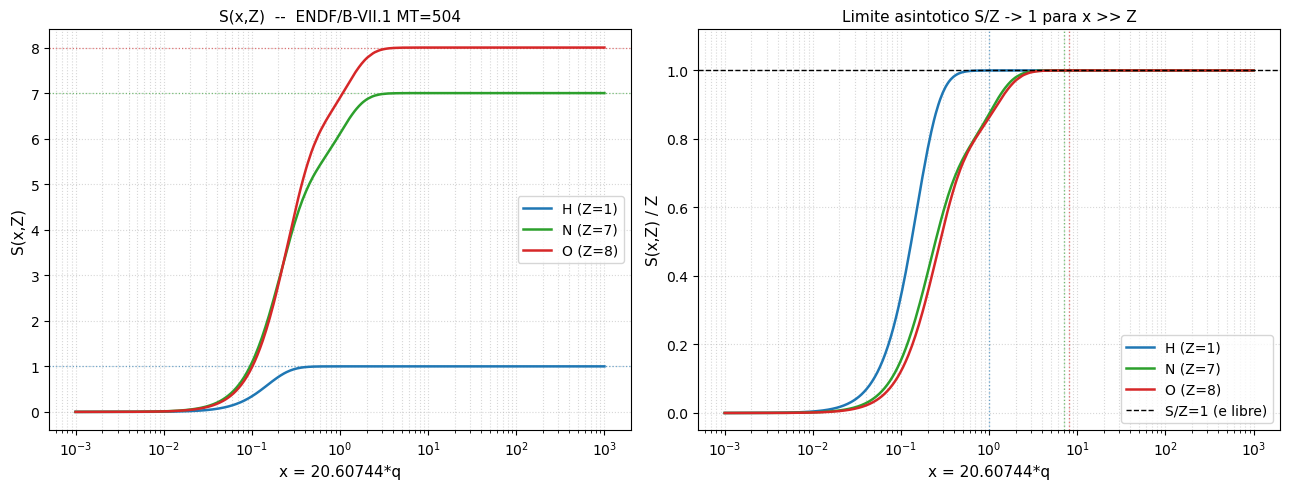

  Limite S(x,Z)/Z -> 1  [tol 5Z=5e-03, 100Z=1e-04]
  Elem    Z     S(Z)/Z    |1-S/Z|@5Z    |1-S/Z|@100Z    OK
     H    1    0.99995     0.000e+00       0.000e+00    OK
     N    7    0.99999     1.110e-16       1.110e-16    OK
     O    8    1.00000     2.220e-16       2.220e-16    OK
  Global: OK


In [7]:
# CELDA 5 -- Verificacion de S(x,Z)
import numpy as np, matplotlib.pyplot as plt

x_grid = np.logspace(-3, 3, 600)
ELEMS  = ['H','N','O']
COL    = {'H':'tab:blue','N':'tab:green','O':'tab:red'}
Smat   = {el: np.array([_interp_scatter_function(x, el) for x in x_grid]) for el in ELEMS}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for el in ELEMS:
    Z = Z_ATOMIC[el]
    ax1.plot(x_grid, Smat[el], color=COL[el], lw=1.8, label=f'{el} (Z={Z})')
    ax1.axhline(Z, color=COL[el], ls=':', lw=0.9, alpha=0.6)
ax1.set_xscale('log')
ax1.set_xlabel('x = 20.60744*q', fontsize=11)
ax1.set_ylabel('S(x,Z)', fontsize=11)
ax1.set_title('S(x,Z)  --  ENDF/B-VII.1 MT=504', fontsize=11)
ax1.legend(fontsize=10)
ax1.grid(True, which='both', ls=':', alpha=0.5)

for el in ELEMS:
    Z = Z_ATOMIC[el]
    ax2.plot(x_grid, Smat[el]/Z, color=COL[el], lw=1.8, label=f'{el} (Z={Z})')
    ax2.axvline(Z, color=COL[el], ls=':', lw=1.0, alpha=0.6)
ax2.axhline(1.0, color='k', ls='--', lw=1.0, label='S/Z=1 (e libre)')
ax2.set_xscale('log')
ax2.set_xlabel('x = 20.60744*q', fontsize=11)
ax2.set_ylabel('S(x,Z) / Z', fontsize=11)
ax2.set_title('Limite asintotico S/Z -> 1 para x >> Z', fontsize=11)
ax2.legend(fontsize=10)
ax2.grid(True, which='both', ls=':', alpha=0.5)
ax2.set_ylim(-0.05, 1.12)
plt.tight_layout(); plt.show()

# ── Tabla numerica ───────────────────────────────────────────────────────
TOL_5Z, TOL_100Z = 5e-3, 1e-4
sep = '='*62
print(sep)
print('  Limite S(x,Z)/Z -> 1  [tol 5Z={:.0e}, 100Z={:.0e}]'.format(TOL_5Z, TOL_100Z))
print(sep)
print(f"  {'Elem':>4}  {'Z':>3}  {'S(Z)/Z':>9}  {'|1-S/Z|@5Z':>12}  {'|1-S/Z|@100Z':>14}  {'OK':>4}")
ok_all = True
for el in ELEMS:
    Z = Z_ATOMIC[el]
    sz   = _interp_scatter_function(float(Z), el) / Z
    e5   = abs(1.0 - _interp_scatter_function(5.0*Z, el)/Z)
    e100 = abs(1.0 - _interp_scatter_function(100.0*Z, el)/Z)
    ok   = e5 < TOL_5Z and e100 < TOL_100Z
    ok_all = ok_all and ok
    print(f'  {el:>4}  {Z:>3}  {sz:>9.5f}  {e5:>12.3e}  {e100:>14.3e}  {"OK" if ok else "FALLO":>4}')
print(sep)
print(f'  Global: {"OK" if ok_all else "FALLO"}')
print(sep)

## Celda 6 — Verificacion XS puntuales vs xraydb / NIST

Compara `mu/rho` [cm2/g] del codigo frente a tablas Elam via xraydb.
Materiales: H2O y Aire. Rango: 20-80 keV. Procesos: PE, Compton, total.

Ref: Hubbell et al. (1975); NIST-XCOM; xraydb (tablas Elam).


  mu/rho [cm2/g]  H2O  -- codigo vs xraydb/NIST  (20-80 keV)
 E   PE_ref   PE_cod  err_PE  C_ref  C_cod     err_C  T_ref  T_cod     err_T
20   0.5439   0.5444 0.08643 0.1774 0.1773  -0.01102 0.7213 0.7217   0.06246
25    0.264   0.2636 -0.1707 0.1812 0.1812  0.002261 0.4452 0.4448   -0.1003
30   0.1458   0.1456 -0.1087 0.1829 0.1829 -0.003449 0.3287 0.3285  -0.05011
35  0.08802  0.08805 0.02732 0.1832 0.1832 -0.008964 0.2713 0.2713   0.00281
40  0.05679  0.05687  0.1325 0.1827 0.1827  -0.01567 0.2395 0.2396   0.01945
45  0.03856  0.03862  0.1661 0.1817 0.1817  -0.01603 0.2203 0.2203   0.01585
50  0.02725  0.02729  0.1554 0.1803 0.1803   -0.0156 0.2076 0.2076  0.006842
55   0.0199  0.01992   0.122 0.1787 0.1787  -0.01949 0.1986 0.1986 -0.005315
60  0.01493  0.01494 0.05883  0.177  0.177  -0.02316  0.192 0.1919  -0.01678
65  0.01146  0.01145 -0.0283 0.1752 0.1752  -0.02326 0.1867 0.1867  -0.02357
70  0.00897 0.008959 -0.1153 0.1734 0.1734  -0.02105 0.1824 0.1823  -0.02568
75 0.007141 0.0

/tmp/ipykernel_934/239145272.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


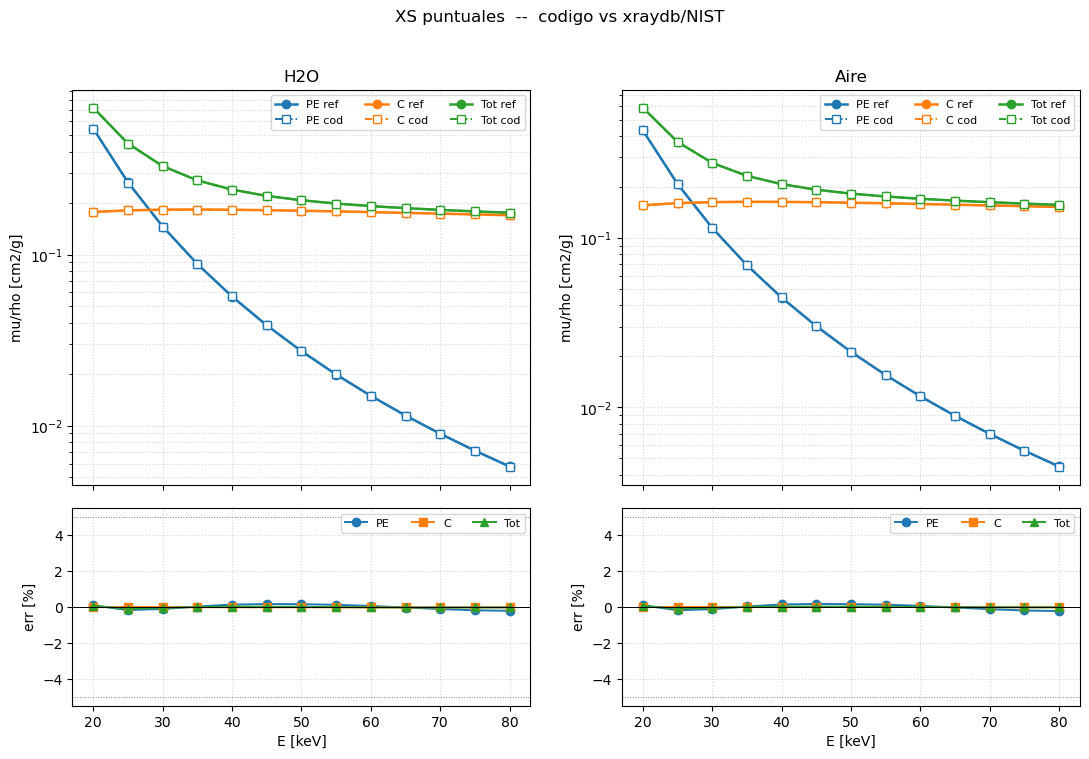

In [8]:
# CELDA 6 -- Verificacion XS puntuales vs xraydb / NIST
import numpy as np, pandas as pd, matplotlib.pyplot as plt

E_TEST = [20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80]

if not _XRAYDB_OK:
    print('WARNING  xraydb no disponible -- omitiendo Celda 6.')
    print('         Instala con:  pip install xraydb')
else:
    # xraydb.material_mu() devuelve mu [cm^-1] (ya multiplicado por rho),
    # xraydb.mu_elam()       devuelve mu/rho [cm2/g].
    # Para comparar con photoelectric_mu_over_rho / compton_mu_over_rho
    # (que devuelven mu/rho [cm2/g]) usamos siempre mu_elam con
    # las fracciones masicas correctas de cada material.
    H2O_WFRAC  = {'H': 0.111898, 'O': 0.888102}
    AIRE_WFRAC = {'N': 0.78,     'O': 0.22}

    def _xrdb_mu_over_rho(E_eV, kind, wfrac):
        """mu/rho [cm2/g] via xraydb.mu_elam (fracciones masicas)."""
        return sum(w * xraydb.mu_elam(el, E_eV, kind=kind) for el, w in wfrac.items())

    MATS = [
        ('H2O',  COMP_H2O, RHO_H2O, H2O_WFRAC),
        ('Aire', COMP_AIR, RHO_AIR,  AIRE_WFRAC),
    ]
    res6 = {}
    for name, comp, rho, wfrac in MATS:
        rows = []
        for E in E_TEST:
            pe_r = _xrdb_mu_over_rho(E*1000.0, 'photo', wfrac)
            co_r = _xrdb_mu_over_rho(E*1000.0, 'incoh', wfrac)
            pe_c = xs.photoelectric_mu_over_rho(float(E), comp)
            co_c = xs.compton_mu_over_rho(float(E), comp)
            rows.append({'E':E,
                'PE_ref':pe_r,'PE_cod':pe_c,
                'err_PE':100*(pe_c-pe_r)/pe_r if pe_r>1e-30 else float('nan'),
                'C_ref': co_r,'C_cod': co_c,
                'err_C': 100*(co_c-co_r)/co_r if co_r>1e-30 else float('nan'),
                'T_ref': pe_r+co_r,'T_cod':pe_c+co_c,
                'err_T': 100*((pe_c+co_c)-(pe_r+co_r))/(pe_r+co_r) if (pe_r+co_r)>1e-30 else float('nan'),
            })
        res6[name] = pd.DataFrame(rows)

    pd.set_option('display.float_format', lambda x: f'{x:.4g}')
    pd.set_option('display.width', 200)
    for name, df in res6.items():
        print('='*96)
        print(f'  mu/rho [cm2/g]  {name}  -- codigo vs xraydb/NIST  (20-80 keV)')
        print('='*96)
        print(df[['E','PE_ref','PE_cod','err_PE','C_ref','C_cod','err_C','T_ref','T_cod','err_T']].to_string(index=False))
        print(f'  |err|max:  PE={df.err_PE.abs().max():.2f}%  C={df.err_C.abs().max():.2f}%  T={df.err_T.abs().max():.2f}%')
        print()

    fig, axes = plt.subplots(2, 2, figsize=(13,8),
                             gridspec_kw={'height_ratios':[3,1.5],'hspace':0.08})
    PC = {'PE':'tab:blue','C':'tab:orange','T':'tab:green'}
    for col, (name, _, _, _) in enumerate(MATS):
        df = res6[name]; E = df.E.values
        ax = axes[0,col]
        ax.plot(E, df.PE_ref,'o-', color=PC['PE'],lw=1.8,label='PE ref')
        ax.plot(E, df.PE_cod,'s--',color=PC['PE'],lw=1.4,mfc='w',label='PE cod')
        ax.plot(E, df.C_ref, 'o-', color=PC['C'], lw=1.8,label='C ref')
        ax.plot(E, df.C_cod, 's--',color=PC['C'], lw=1.4,mfc='w',label='C cod')
        ax.plot(E, df.T_ref, 'o-', color=PC['T'], lw=1.8,label='Tot ref')
        ax.plot(E, df.T_cod, 's--',color=PC['T'], lw=1.4,mfc='w',label='Tot cod')
        ax.set_yscale('log'); ax.set_ylabel('mu/rho [cm2/g]')
        ax.set_title(name); ax.grid(True,which='both',ls=':',alpha=0.5)
        ax.legend(ncol=3,fontsize=8); ax.set_xticklabels([])
        ax = axes[1,col]
        ax.plot(E, df.err_PE,'o-',color=PC['PE'],lw=1.4,label='PE')
        ax.plot(E, df.err_C, 's-',color=PC['C'], lw=1.4,label='C')
        ax.plot(E, df.err_T, '^-',color=PC['T'], lw=1.4,label='Tot')
        ax.axhline(0,color='k',lw=0.7)
        for yv in [5,-5]: ax.axhline(yv,color='grey',ls=':',lw=0.7)
        ax.set_xlabel('E [keV]'); ax.set_ylabel('err [%]')
        ax.grid(True,ls=':',alpha=0.5); ax.legend(ncol=3,fontsize=8)
    fig.suptitle('XS puntuales  --  codigo vs xraydb/NIST',fontsize=12)
    plt.tight_layout(); plt.show()

## Celda 7 — Verificacion XS por elemento y aditividad de Bragg

Compara `mu/rho` por elemento H, N, O contra xraydb y verifica aditividad de Bragg
en H2O y Aire:

  mu_mat = sum_i w_i * mu_i(E)  [Vassiliev Sec.3.1]


In [9]:
# CELDA 7 -- Verificacion por elemento y aditividad de Bragg

if not _XRAYDB_OK:
    print('WARNING  xraydb no disponible -- omitiendo tabla por elemento.')
else:
    print('='*88)
    print('  mu/rho [cm2/g] por elemento puro  --  codigo vs xraydb/Elam')
    print('='*88)
    for el in ['H','N','O']:
        cp0 = comp_pure(el)
        rows = []
        for E in [20,30,40,50,60,70,80]:
            pe_r = xraydb.mu_elam(el, E*1000.0, kind='photo')
            co_r = xraydb.mu_elam(el, E*1000.0, kind='incoh')
            pe_c = xs.photoelectric_mu_over_rho(float(E), cp0)
            co_c = xs.compton_mu_over_rho(float(E), cp0)
            rows.append({'E':E,
                'PE_ref':pe_r,'PE_cod':pe_c,'err_PE_%':100*(pe_c-pe_r)/pe_r if pe_r>1e-30 else float('nan'),
                'C_ref': co_r,'C_cod': co_c,'err_C_%': 100*(co_c-co_r)/co_r  if co_r>1e-30 else float('nan')})
        df7 = pd.DataFrame(rows)
        print(f'  {el}  (Z={Z_ATOMIC[el]}, A={A_ATOMIC[el]:.5g})')
        print(df7.to_string(index=False))
        print(f'  |err|max:  PE={df7.err_PE_pct.abs().max() if "err_PE_pct" in df7 else df7["err_PE_%"].abs().max():.2f}%  C={df7["err_C_%"].abs().max():.2f}%')
        print()

# ── Aditividad de Bragg ──────────────────────────────────────────────────
print('='*80)
print('  Aditividad de Bragg: mu_mat = sum_i w_i * mu_i  (Compton, H2O y Aire)')
print('='*80)
for name, comp, rho in [('H2O',COMP_H2O,RHO_H2O),('Aire',COMP_AIR,RHO_AIR)]:
    print(f'  {name} (rho={rho} g/cm3)')
    print(f"  {'E [keV]':>8}  {'Compton mix':>14}  {'Bragg sum':>14}  {'err [%]':>9}")
    for E in [20,30,40,50,60,70,80]:
        co_m = xs.compton_mu_over_rho(float(E), comp)
        co_b = sum(
            float(comp[el].values[0])/100.0 * xs.compton_mu_over_rho(float(E), comp_pure(el))
            for el in xs._elements if float(comp[el].values[0]) > 0
        )
        err = 100*(co_m-co_b)/co_b if co_b>1e-30 else float('nan')
        print(f'  {E:>8}  {co_m:>14.5e}  {co_b:>14.5e}  {err:>+8.4f}%')
    print()

  mu/rho [cm2/g] por elemento puro  --  codigo vs xraydb/Elam
  H  (Z=1, A=1.0079)
 E    PE_ref    PE_cod  err_PE_%  C_ref  C_cod   err_C_%
20 0.0002499 0.0002502    0.1267 0.3626 0.3625 -0.008624
30 6.167e-05 6.157e-05   -0.1585  0.354 0.3539 -0.001892
40 2.284e-05 2.287e-05    0.1305 0.3441 0.3441  -0.01169
50 1.058e-05  1.06e-05    0.1955 0.3344 0.3344  -0.01238
60 5.649e-06 5.654e-06   0.08002 0.3253 0.3252  -0.01784
70 3.327e-06 3.323e-06   -0.1208 0.3167 0.3166  -0.01708
80 2.105e-06   2.1e-06   -0.2339 0.3087 0.3086  -0.01281
  |err|max:  PE=0.23%  C=0.02%

  N  (Z=7, A=14.007)
 E   PE_ref   PE_cod  err_PE_%  C_ref  C_cod   err_C_%
20   0.3808   0.3811   0.09968 0.1567 0.1567 -0.008278
30    0.101   0.1008   -0.1271 0.1634 0.1634   0.00446
40  0.03906  0.03912    0.1477 0.1639 0.1638 -0.004819
50  0.01866  0.01869    0.1616 0.1619 0.1619  0.007489
60  0.01019  0.01019   0.07002 0.1591 0.1591  0.007675
70 0.006105 0.006097   -0.1228 0.1559 0.1559  -0.00458
80 0.003919  0.00391   

## Celda 8 — Verificacion multigrupo vs NJOY/GAMINR iwt=2

### Bloque 8A — Codigo vs referencia puntual colapsada (xraydb, peso plano)
Referencia interna: misma formula de colapso (`w=1`) aplicada a xraydb.

### Bloque 8B — Codigo vs tapes GENDF NJOY/GAMINR (`iwt=2`)
Lee MF=23 (MT=501, 504, 522) de los tapes GENDF. Total = MT501 - MT502.

**NOTA:** la comparacion con NJOY es valida SOLO para `iwt=2` (peso plano).  
Para otros pesos generar tapes NJOY con el `iwt` correspondiente.

Ref: NJOY GAMINR Eq.(384); ENDF-6 MF=23.


In [10]:
# CELDA 8 -- Verificacion multigrupo vs NJOY/GAMINR
# Estructura identica a V2 + V4 del notebook de referencia (iwt_2_sec).
# 8A: codigo vs xraydb colapsado (peso plano).
# 8B: codigo vs tapes GENDF NJOY -- peso plano (iwt=2, w(E)=1).
#     8B.1 por elemento [barns/atomo]  (= V2/V4.1 del ref.)
#     8B.2 mezcla Bragg [cm^-1]        (= V4.2 del ref.)
import numpy as np, pandas as pd, re
from pathlib import Path

# =========================================================================
# 8A -- Codigo vs xraydb colapsado con peso plano (iwt=2)
# =========================================================================
if not _XRAYDB_OK:
    print('WARNING  xraydb no disponible -- omitiendo Bloque 8A.')
else:
    # Siempre usamos mu_elam (-> mu/rho [cm2/g]) y multiplicamos por rho
    # para obtener sigma [cm^-1]. Evita la inconsistencia de material_mu.
    H2O_WFRAC8A  = {'H': 0.111898, 'O': 0.888102}
    AIRE_WFRAC8A = {'N': 0.78,     'O': 0.22}

    def _xrdb_mu_over_rho_8a(E_eV, kind, wfrac):
        """mu/rho [cm2/g] via mu_elam."""
        return sum(w * xraydb.mu_elam(el, E_eV, kind=kind) for el, w in wfrac.items())

    def _xrdb_avg_g(g, kind, wfrac):
        bins = energy_bins_in_range(g)
        return float(np.mean([_xrdb_mu_over_rho_8a(E*1000., kind, wfrac) for E in bins])) if bins else 0.0

    MATS8A = [('H2O',  COMP_H2O, RHO_H2O, H2O_WFRAC8A),
              ('Aire', COMP_AIR, RHO_AIR,  AIRE_WFRAC8A)]
    rows8a = []
    for name, comp, rho, wfrac in MATS8A:
        for lbl, gb in zip(GROUP_LABELS, GROUP_BTE_IDX):
            pe_r = _xrdb_avg_g(gb, 'photo', wfrac) * rho
            co_r = _xrdb_avg_g(gb, 'incoh', wfrac) * rho
            tt_r = pe_r+co_r
            pe_c = mg_xs.sigma_pe_g(gb,rho,comp)
            co_c = mg_xs.sigma_compton_g(gb,rho,comp)
            tt_c = pe_c+co_c
            rows8a.append({'Mat':name,'Grupo':lbl,
                'PE_ref':pe_r,'PE_cod':pe_c,'err_PE':100*(pe_c-pe_r)/pe_r if pe_r>0 else float('nan'),
                'C_ref': co_r,'C_cod': co_c,'err_C': 100*(co_c-co_r)/co_r  if co_r>0 else float('nan'),
                'T_ref': tt_r,'T_cod': tt_c,'err_T': 100*(tt_c-tt_r)/tt_r  if tt_r>0 else float('nan')})
    df8a = pd.DataFrame(rows8a)
    pd.set_option('display.float_format', lambda x: f'{x:.4g}')
    print('='*100)
    print('  8A -- sigma_g [cm^-1]  codigo vs xraydb colapsado  (peso plano, iwt=2)')
    print('='*100)
    for name in ('H2O','Aire'):
        s = df8a[df8a.Mat==name]
        print(f'  {name}:')
        print(s.drop(columns='Mat').to_string(index=False))
        print(f'  |err|max:  PE={s.err_PE.abs().max():.2f}%  C={s.err_C.abs().max():.2f}%  T={s.err_T.abs().max():.2f}%')
        print()

# =========================================================================
# 8B -- Codigo vs tapes GENDF NJOY/GAMINR
# =========================================================================
# Rutas a los tapes GENDF. Ajusta si es necesario.
TAPE_HO = '/home/rober/njoy_work/tapes/gendf_HO_0_100_10keV_lord3_iwt2'
TAPE_N  = '/home/rober/njoy_work/tapes/gendf_N_0_100_10keV_lord3_iwt2'   

def _gd_float(s):
    s = s.strip()
    if not s: return 0.0
    try: return float(s)
    except ValueError:
        m = re.match(r'\s*([+-]?\d+\.?\d*)([+-]\d+)\s*$', s)
        if m: return float(m.group(1)+'e'+m.group(2))
        raise

def _gd_split(line):
    if len(line) < 66: line = line.ljust(66)
    return [line[i*11:(i+1)*11] for i in range(6)], line[66:70].strip(), line[70:72].strip(), line[72:75].strip()

def parse_gendf(filepath):
    """Lee MF=23 de un tape GENDF NJOY. Identico al parser del notebook de referencia."""
    lines = Path(filepath).read_text(errors='ignore').splitlines()
    blocks = {}
    for ln in lines:
        if len(ln) < 75: continue
        _, mat, mf, mt = _gd_split(ln)
        try: mat,mf,mt = int(mat),int(mf),int(mt)
        except ValueError: continue
        if mat<=0 or mf==0 or mt==0: continue
        blocks.setdefault((mat,mf,mt),[]).append(ln)
    data = {}
    for mat in sorted({k[0] for k in blocks}):
        d = {'xs_vector':{},'energy_bounds_eV':None,'ngroups':None}
        if (mat,1,451) in blocks:
            fls = []
            for ln in blocks[(mat,1,451)][2:]:
                for f in _gd_split(ln)[0]:
                    if f.strip():
                        try: fls.append(_gd_float(f))
                        except: pass
            cands = sorted({v for v in fls if 0.0 <= v <= 1e12})
            if len(cands) >= 2:
                d['energy_bounds_eV'] = np.array(cands, dtype=float)
                d['ngroups'] = len(cands) - 1
        NG = d['ngroups']
        if NG is None: continue
        for mtx in (501, 502, 504, 522):
            if (mat,23,mtx) not in blocks: continue
            blk = blocks[(mat,23,mtx)]
            xa = np.zeros(NG)
            i = 1
            while i < len(blk):
                flds,*_ = _gd_split(blk[i])
                try: nw,ig = int(_gd_float(flds[4])),int(_gd_float(flds[5]))
                except: i+=1; continue
                if nw<=0 or ig<=0: i+=1; continue
                vals = []
                nl = (nw+5)//6
                for j in range(1, nl+1):
                    if i+j >= len(blk): break
                    for f in _gd_split(blk[i+j])[0]:
                        if f.strip() and len(vals)<nw: vals.append(_gd_float(f))
                if nw==2 and 1<=ig<=NG and len(vals)>=2: xa[ig-1] = vals[1]
                i += 1+nl
            d['xs_vector'][mtx] = xa
        data[mat] = d
    return data

MAT_INFO = {100:('H',1,1.00794), 800:('O',8,15.9994), 700:('N',7,14.0067)}

if not any(Path(p).exists() for p in [TAPE_HO, TAPE_N]):
    print('INFO  Tapes NJOY no encontrados. Ajusta TAPE_HO y TAPE_N.')
    print(f'      TAPE_HO = {TAPE_HO}')
    print(f'      TAPE_N  = {TAPE_N}')
else:
    njoy_raw = {}
    for tp in [TAPE_HO, TAPE_N]:
        if Path(tp).exists():
            try: njoy_raw.update(parse_gendf(tp))
            except Exception as e: print(f'WARNING {tp}: {e}')

    njoy_by_elem = {MAT_INFO[m][0]: {**d,'Z':MAT_INFO[m][1],'A':MAT_INFO[m][2]}
                   for m,d in njoy_raw.items() if m in MAT_INFO}
    NG_NJOY      = next(iter(njoy_by_elem.values()))['ngroups']
    E_BOUNDS_KEV = next(iter(njoy_by_elem.values()))['energy_bounds_eV'] / 1000.0
    N_AV         = 6.02214076e23

    print(f'OK  Tapes leidos: {list(njoy_by_elem.keys())}  ({NG_NJOY} grupos)')
    print(f'    Malla: {NG_NJOY} grupos,  bordes = {E_BOUNDS_KEV} keV')
    print()

    # Mapeo NJOY (asc, baja->alta E) <-> BTE (desc, alta->baja E)
    # Identico al del notebook de referencia (V4).
    GROUP_LABELS_V4 = ['20-30 keV','30-40 keV','40-50 keV','50-60 keV','60-70 keV','70-80 keV']
    GROUP_NJOY_V4   = [2, 3, 4, 5, 6, 7]   # indices 0-based en el tape
    GROUP_BTE_V4    = [7, 6, 5, 4, 3, 2]   # indices 0-based en BTE

    # ── Peso del colapso: iwt=2 (plano, w(E)=1) ──────────────────────────
    # Este notebook es exclusivamente para NJOY/GAMINR iwt=2.
    # El tape DEBE haber sido generado con iwt=2 (constante).
    # No se necesita deteccion automatica.
    def _w_code(E):
        return 1.0   # peso plano, NJOY iwt=2

    peso_label = 'iwt=2  (plano, w=1)'
    print(f'    Peso codigo: {peso_label}')
    print()

    
    # ── 8B.1 -- Por elemento [barns/atomo] ────────────────────────────────
    # Funcion identica a code_sigma_per_atom del notebook de referencia (V2/V4.1).
    # Usa E_lo, E_hi del TAPE (no hardcodeados) para los bins del codigo.
    def _sigma_cod_per_atom(elem, mt_kind, E_lo_keV, E_hi_keV):
        """sigma_g [barns/atomo] del codigo para elemento puro.
        Usa los limites E_lo, E_hi del tape y el peso _w_code.
        """
        A = njoy_by_elem[elem]['A']
        comp = pd.DataFrame({'H':[0.0],'O':[0.0],'N':[0.0]})
        comp[elem] = 100.0
        bins = np.arange(E_lo_keV + 0.5, E_hi_keV, 1.0)
        if len(bins) == 0: return 0.0
        num = den = 0.0
        for E in bins:
            w = _w_code(E)
            if mt_kind == 'compton':
                mu_rho = xs.compton_mu_over_rho(float(E), comp)
            else:
                mu_rho = xs.photoelectric_mu_over_rho(float(E), comp)
            num += mu_rho * w
            den += w
        return (num/den) * A / N_AV * 1e24 if den > 0 else 0.0

    print('='*108)
    print(f'  8B.1 -- sigma_g [barns/atomo]  codigo vs NJOY  ({peso_label})')
    print('='*108)
    rows_elem = []
    for elem in ('H','N','O'):
        if elem not in njoy_by_elem: continue
        for i_g, label in enumerate(GROUP_LABELS_V4):
            j    = GROUP_NJOY_V4[i_g]
            E_lo = float(E_BOUNDS_KEV[j])
            E_hi = float(E_BOUNDS_KEV[j+1])
            sig_C_nj  = float(njoy_by_elem[elem]['xs_vector'].get(504, np.zeros(NG_NJOY))[j])
            sig_PE_nj = float(njoy_by_elem[elem]['xs_vector'].get(522, np.zeros(NG_NJOY))[j])
            sig_T_nj  = (float(njoy_by_elem[elem]['xs_vector'].get(501, np.zeros(NG_NJOY))[j])
                         - float(njoy_by_elem[elem]['xs_vector'].get(502, np.zeros(NG_NJOY))[j]))
            sig_C_cod  = _sigma_cod_per_atom(elem,'compton',E_lo,E_hi)
            sig_PE_cod = _sigma_cod_per_atom(elem,'photo',  E_lo,E_hi)
            sig_T_cod  = sig_C_cod + sig_PE_cod
            rows_elem.append({'Elem':elem,'Grupo':label,
                'C_NJOY':sig_C_nj,  'C_cod':sig_C_cod,
                'errC_%':100*(sig_C_cod -sig_C_nj) /sig_C_nj  if sig_C_nj >0 else float('nan'),
                'PE_NJOY':sig_PE_nj,'PE_cod':sig_PE_cod,
                'errPE_%':100*(sig_PE_cod-sig_PE_nj)/sig_PE_nj if sig_PE_nj>0 else float('nan'),
                'T_NJOY':sig_T_nj,  'T_cod':sig_T_cod,
                'errT_%':100*(sig_T_cod -sig_T_nj) /sig_T_nj  if sig_T_nj >0 else float('nan')})
    df_elem = pd.DataFrame(rows_elem)

    # ── Chequeo de consistencia: PE 20-30 keV anomalo sugiere tape equivocado
    sub20 = df_elem[df_elem['Grupo'] == '20-30 keV']
    if not sub20.empty and sub20['errPE_%'].abs().max() > 5.0:
        print('WARNING: PE 20-30 keV frente a NJOY es anomalo (>5%).')
        print('         Si 8A sale bien, revisa los tapes GENDF actuales antes de culpar al solver.')
    pd.set_option('display.float_format', lambda x: f'{x:.4g}')
    pd.set_option('display.width', 220)
    for elem in ('H','N','O'):
        sub = df_elem[df_elem.Elem==elem]
        print(f'  -- {elem}  (Z={njoy_by_elem[elem]["Z"]}, A={njoy_by_elem[elem]["A"]:.5g} g/mol) --')
        print(sub.drop(columns='Elem').to_string(index=False))
        print(f'  |err|max:  C={sub["errC_%"].abs().max():.2f}%  PE={sub["errPE_%"].abs().max():.2f}%  T={sub["errT_%"].abs().max():.2f}%')
        print()

    # ── 8B.2 -- Mezcla Bragg [cm^-1] ──────────────────────────────────────
    # Identico a V4.2 del notebook de referencia.
    MIX_H2O = {'H':0.111898,'O':0.888102}
    MIX_AIR = {'N':0.78,'O':0.22}
    RHO_MIX = {'H2O':RHO_H2O,'Aire':RHO_AIR}
    COMPS   = {'H2O':COMP_H2O,'Aire':COMP_AIR}
    MIXES   = {'H2O':MIX_H2O,'Aire':MIX_AIR}

    def _mu_mix_njoy(j_njoy, mt, mix, rho):
        mu = 0.0
        for el, w in mix.items():
            sig = float(njoy_by_elem[el]['xs_vector'].get(mt, np.zeros(NG_NJOY))[j_njoy])
            mu += w * (N_AV / njoy_by_elem[el]['A']) * sig * 1e-24
        return rho * mu

    def _mu_mix_cod(comp, rho, g_bte):
        bins = energy_bins_in_range(g_bte)
        num_C = den_C = 0.0
        num_PE = den_PE = 0.0
        for E in bins:
            w = _w_code(E)
            num_C  += w * xs.macroscopic_compton(float(E), rho, comp);       den_C  += w
            num_PE += w * xs.macroscopic_photoelectric(float(E), rho, comp); den_PE += w
        mu_C  = num_C /den_C  if den_C  > 0 else 0.0
        mu_PE = num_PE/den_PE if den_PE > 0 else 0.0
        return mu_C, mu_PE

    print('='*108)
    print(f'  8B.2 -- sigma_g [cm^-1] mezcla  codigo vs NJOY  ({peso_label})')
    print('  sigma_T_NJOY = MT501 - MT502  (total sin Rayleigh, Vassiliev Sec.3.1)')
    print('='*108)
    rows_mix = []
    for name in ('H2O','Aire'):
        mix  = MIXES[name]
        comp = COMPS[name]
        rho  = RHO_MIX[name]
        for i_g, label in enumerate(GROUP_LABELS_V4):
            j     = GROUP_NJOY_V4[i_g]
            g_bte = GROUP_BTE_V4[i_g]
            mu_C_nj  = _mu_mix_njoy(j, 504, mix, rho)
            mu_PE_nj = _mu_mix_njoy(j, 522, mix, rho)
            mu_T_nj  = _mu_mix_njoy(j, 501, mix, rho) - _mu_mix_njoy(j, 502, mix, rho)
            mu_C_cod, mu_PE_cod = _mu_mix_cod(comp, rho, g_bte)
            mu_T_cod = mu_C_cod + mu_PE_cod
            rows_mix.append({'Mat':name,'Grupo':label,
                'C_NJOY':mu_C_nj,  'C_cod':mu_C_cod,
                'errC_%':100*(mu_C_cod -mu_C_nj) /mu_C_nj  if mu_C_nj >0 else float('nan'),
                'PE_NJOY':mu_PE_nj,'PE_cod':mu_PE_cod,
                'errPE_%':100*(mu_PE_cod-mu_PE_nj)/mu_PE_nj if mu_PE_nj>0 else float('nan'),
                'T_NJOY':mu_T_nj,  'T_cod':mu_T_cod,
                'errT_%':100*(mu_T_cod -mu_T_nj) /mu_T_nj  if mu_T_nj >0 else float('nan')})
    df_mix = pd.DataFrame(rows_mix)
    for name in ('H2O','Aire'):
        sub = df_mix[df_mix.Mat==name]
        print(f'  {name} (rho={RHO_MIX[name]} g/cm3):')
        print(sub.drop(columns='Mat').to_string(index=False))
        print(f'  |err|max:  C={sub["errC_%"].abs().max():.2f}%  PE={sub["errPE_%"].abs().max():.2f}%  T={sub["errT_%"].abs().max():.2f}%')
        print()

  8A -- sigma_g [cm^-1]  codigo vs xraydb colapsado  (peso plano, iwt=2)
  H2O:
Grupo   PE_ref   PE_cod   err_PE  C_ref  C_cod      err_C  T_ref  T_cod     err_T
20-30   0.2895   0.2892  -0.1022 0.1808 0.1808 -0.0009859 0.4704 0.4701  -0.06328
30-40   0.0923   0.0923 0.002765 0.1831 0.1831  -0.008826 0.2754 0.2754 -0.004941
40-50  0.03968  0.03975   0.1573 0.1816 0.1816   -0.01613 0.2213 0.2214   0.01495
50-60  0.02029  0.02031   0.1218 0.1787 0.1787   -0.01952  0.199  0.199 -0.005112
60-70  0.01162  0.01162 -0.02086 0.1752 0.1752   -0.02273 0.1869 0.1868  -0.02261
70-80 0.007216 0.007204   -0.173 0.1716 0.1715   -0.01808 0.1788 0.1787  -0.02433
  |err|max:  PE=0.17%  C=0.02%  T=0.06%

  Aire:
Grupo    PE_ref    PE_cod   err_PE     C_ref     C_cod     err_C     T_ref     T_cod     err_T
20-30 0.0002749 0.0002746  -0.1057 0.0001924 0.0001924  0.004328 0.0004673  0.000467  -0.06038
30-40 8.709e-05 8.709e-05 0.000733 0.0001962 0.0001962 -0.003218 0.0002833 0.0002833 -0.002004
40-50 3.729e

## Celda 9 — Sanity checks compactos

Comprobaciones de consistencia interna de XS puntuales y multigrupo.  
No requieren referencias externas.


In [11]:
# CELDA 9 -- Sanity checks
import math, numpy as np

SEP = '='*60
print(SEP)
print('  Sanity checks de consistencia interna')
print(SEP)
ok_all = True

# S1: mu_t = mu_PE + mu_C (puntuales)
print('  S1  mu_t = mu_PE + mu_C  (5 energias, H2O y Aire)')
for name,comp,rho in [('H2O',COMP_H2O,RHO_H2O),('Aire',COMP_AIR,RHO_AIR)]:
    for E in [20.,35.,50.,65.,80.]:
        pe = xs.macroscopic_photoelectric(E,rho,comp)
        co = xs.macroscopic_compton(E,rho,comp)
        tt = xs.macroscopic_total(E,rho,comp)
        err = abs(tt-(pe+co))/tt if tt>0 else 0.0
        ok  = err < 1e-10; ok_all = ok_all and ok
        print(f'    {name:>5}  E={E:5.1f}  PE={pe:.4e}  C={co:.4e}  t={tt:.4e}  err={err:.2e}  {"OK" if ok else "FALLO"}')

# S2: sigma_t_g > 0 en todos los grupos activos
print('  S2  sigma_t_g > 0  (grupos activos, iwt=2)')
for name,comp,rho in [('H2O',COMP_H2O,RHO_H2O),('Aire',COMP_AIR,RHO_AIR)]:
    for g in active_groups():
        hi,lo = ENERGY_GROUPS[g]
        sg = mg_xs.sigma_total_g(g,rho,comp)
        ok = sg > 0.0; ok_all = ok_all and ok
        print(f'    {name:>5}  g={g} ({lo}-{hi} keV)  sigma_t_g={sg:.4e}  {"OK" if ok else "FALLO"}')

# S3: sigma_C_g <= sigma_T_g
print('  S3  sigma_C_g <= sigma_T_g')
for name,comp,rho in [('H2O',COMP_H2O,RHO_H2O),('Aire',COMP_AIR,RHO_AIR)]:
    for g in active_groups():
        hi,lo = ENERGY_GROUPS[g]
        sc = mg_xs.sigma_compton_g(g,rho,comp)
        st = mg_xs.sigma_total_g(g,rho,comp)
        ok = sc <= st+1e-14; ok_all = ok_all and ok
        print(f'    {name:>5}  g={g}  C={sc:.4e}  T={st:.4e}  {"OK" if ok else "FALLO"}')

# S4: Bragg multigrupo (H2O: Compton)
print('  S4  Bragg multigrupo: sigma_g_mix = w_H*sigma_H + w_O*sigma_O  (Compton, H2O)')
wH, wO = 0.111898, 0.888102
for g in active_groups():
    hi,lo = ENERGY_GROUPS[g]
    cm = mg_xs.sigma_compton_g(g,RHO_H2O,COMP_H2O)
    cH = mg_xs.sigma_compton_g(g,RHO_H2O,pd.DataFrame({'H':[100.],'O':[0.],'N':[0.]}))
    cO = mg_xs.sigma_compton_g(g,RHO_H2O,pd.DataFrame({'H':[0.],'O':[100.],'N':[0.]}))
    cb = wH*cH + wO*cO
    err = abs(cm-cb)/cm if cm>0 else 0.0
    ok  = err < 1e-8; ok_all = ok_all and ok
    print(f'    g={g} ({lo}-{hi} keV)  mix={cm:.4e}  Bragg={cb:.4e}  err={err:.2e}  {"OK" if ok else "FALLO"}')

print()
print(SEP)
print(f'  Resultado global: {"OK" if ok_all else "FALLO"}')
print(SEP)

  Sanity checks de consistencia interna
  S1  mu_t = mu_PE + mu_C  (5 energias, H2O y Aire)
      H2O  E= 20.0  PE=5.4438e-01  C=1.7734e-01  t=7.2171e-01  err=0.00e+00  OK
      H2O  E= 35.0  PE=8.8049e-02  C=1.8322e-01  t=2.7127e-01  err=0.00e+00  OK
      H2O  E= 50.0  PE=2.7293e-02  C=1.8030e-01  t=2.0759e-01  err=0.00e+00  OK
      H2O  E= 65.0  PE=1.1455e-02  C=1.7520e-01  t=1.8665e-01  err=0.00e+00  OK
      H2O  E= 80.0  PE=5.7580e-03  C=1.6970e-01  t=1.7545e-01  err=0.00e+00  OK
     Aire  E= 20.0  PE=5.1856e-04  C=1.8733e-04  t=7.0590e-04  err=0.00e+00  OK
     Aire  E= 35.0  PE=8.3038e-05  C=1.9642e-04  t=2.7946e-04  err=0.00e+00  OK
     Aire  E= 50.0  PE=2.5608e-05  C=1.9404e-04  t=2.1965e-04  err=1.23e-16  OK
     Aire  E= 65.0  PE=1.0711e-05  C=1.8885e-04  t=1.9956e-04  err=0.00e+00  OK
     Aire  E= 80.0  PE=5.3710e-06  C=1.8307e-04  t=1.8844e-04  err=0.00e+00  OK
  S2  sigma_t_g > 0  (grupos activos, iwt=2)
      H2O  g=2 (70-80 keV)  sigma_t_g=1.7874e-01  OK
      H2O 

## Celda 10 — Resumen tecnico final

Tabla de errores maximos por bloque. **Caso NJOY/GAMINR `iwt=2` (peso plano).**


In [12]:
# CELDA 10 -- Resumen tecnico final  [NJOY/GAMINR iwt=2]
import pandas as pd

SEP = '='*72
print(SEP)
print('  RESUMEN FINAL -- NJOY/GAMINR iwt=2 (w(E)=1, peso plano)')
print(SEP)

rows = []

rows.append({'Bloque':'S(x,Z) [C5]','Magnitud':'S/Z->1 limite',
             'Material':'H,N,O','Ref':'ENDF MT=504','Estado':'Ver Celda 5'})

if _XRAYDB_OK and 'res6' in dir():
    for name,df in res6.items():
        rows.append({'Bloque':'XS puntual [C6]',
                     'Magnitud':'mu_PE/rho [cm2/g]',
                     'Material':name,'Ref':'xraydb/NIST',
                     'Estado':f'max={df.err_PE.abs().max():.2f}%'})
        rows.append({'Bloque':'XS puntual [C6]',
                     'Magnitud':'mu_C/rho [cm2/g]',
                     'Material':name,'Ref':'xraydb/NIST',
                     'Estado':f'max={df.err_C.abs().max():.2f}%'})
else:
    rows.append({'Bloque':'XS puntual [C6]','Magnitud':'mu/rho',
                 'Material':'---','Ref':'xraydb/NIST','Estado':'xraydb no disponible'})

if _XRAYDB_OK and 'df8a' in dir():
    for name in ('H2O','Aire'):
        s = df8a[df8a.Mat==name]
        rows.append({'Bloque':'MG vs xraydb iwt=2 [C8A]',
                     'Magnitud':'sigma_g total [cm^-1]',
                     'Material':name,'Ref':'xraydb colapsado iwt=2',
                     'Estado':f'max={s.err_T.abs().max():.2f}%'})
else:
    rows.append({'Bloque':'MG vs xraydb iwt=2 [C8A]','Magnitud':'sigma_g',
                 'Material':'---','Ref':'xraydb iwt=2','Estado':'xraydb no disponible'})

if 'df_elem' in dir():
    for elem in ('H','N','O'):
        s = df_elem[df_elem.Elem==elem]
        rows.append({'Bloque':'MG vs NJOY iwt=2 [C8B.1]',
                     'Magnitud':'sigma_g total [barns/atomo]',
                     'Material':elem,'Ref':'NJOY/GAMINR MF=23 iwt=2',
                     'Estado':f'max_C={s["errC_%"].abs().max():.2f}%  max_PE={s["errPE_%"].abs().max():.2f}%  max_T={s["errT_%"].abs().max():.2f}%'})

if 'df_mix' in dir():
    for name in ('H2O','Aire'):
        s = df_mix[df_mix.Mat==name]
        rows.append({'Bloque':'MG vs NJOY iwt=2 [C8B.2]',
                     'Magnitud':'sigma_g total [cm^-1]',
                     'Material':name,'Ref':'NJOY/GAMINR MF=23 iwt=2',
                     'Estado':f'max_C={s["errC_%"].abs().max():.2f}%  max_PE={s["errPE_%"].abs().max():.2f}%  max_T={s["errT_%"].abs().max():.2f}%'})
else:
    rows.append({'Bloque':'MG vs NJOY iwt=2 [C8B]','Magnitud':'sigma_g',
                 'Material':'---','Ref':'NJOY MF=23 iwt=2','Estado':'Tapes NJOY no encontrados'})

df_res = pd.DataFrame(rows)
pd.set_option('display.width',160); pd.set_option('display.max_colwidth',36)
print(df_res.to_string(index=False))
print()
print(SEP)
print('  Criterio de aceptacion:')
print('    XS puntuales        : |err| < 2%  vs xraydb/NIST  (20-80 keV)')
print('    MG vs ref colapsada : |err| < 1%  (mismo peso plano, determinista)')
print('    MG vs NJOY iwt=2    : |err| < 2%  (diferencias de malla de integracion)')
print(SEP)
print('  Esta tabla es valida SOLO para NJOY/GAMINR iwt=2 (peso plano).')
print(SEP)

  RESUMEN FINAL -- NJOY/GAMINR iwt=2 (w(E)=1, peso plano)
                  Bloque                    Magnitud Material                     Ref                                 Estado
             S(x,Z) [C5]               S/Z->1 limite    H,N,O             ENDF MT=504                            Ver Celda 5
         XS puntual [C6]           mu_PE/rho [cm2/g]      H2O             xraydb/NIST                              max=0.21%
         XS puntual [C6]            mu_C/rho [cm2/g]      H2O             xraydb/NIST                              max=0.02%
         XS puntual [C6]           mu_PE/rho [cm2/g]     Aire             xraydb/NIST                              max=0.23%
         XS puntual [C6]            mu_C/rho [cm2/g]     Aire             xraydb/NIST                              max=0.01%
MG vs xraydb iwt=2 [C8A]       sigma_g total [cm^-1]      H2O  xraydb colapsado iwt=2                              max=0.06%
MG vs xraydb iwt=2 [C8A]       sigma_g total [cm^-1]     Aire  xray